
# Esercizio Stabilità nella soluzione di un'equazione di secondo grado


Per ogni $k \in \mathbb{N}$, si consideri l'equazione

$$
x^2 - 2kx + 1 = 0.
$$

Si considerino i valori

$$
k = 10^1,10^2,\dots,10^{16}.
$$

Le radici possono essere calcolate con la formula risolutiva standard. Tuttavia, per valori grandi di $k$, il calcolo di una delle due radici può essere affetto da instabilità numerica.

### Richieste

1. Implementare in Python la formula risolutiva standard per il calcolo delle due radici.  
**[1 punti]**

2. Calcolare valori di riferimento accurati usando aritmetica in precisione elevata e calcolare gli errori relativi delle due radici.  
**[1 punti]**

3. Rappresentare in scala logaritmica gli errori relativi al variare di $k$.  
**[1 punti]**

4. Osservando i risultati numerici, individuare quale radice è calcolata in modo instabile e spiegare dove avviene la cancellazione di cifre significative e per quali valori di k, facendo uso anche del concetto di spacing.
**[4 punti]**

5. Ricavare una formula matematicamente equivalente ma numericamente più stabile per la radice problematica, motivando il passaggio algebrico.  
**[2 punti]**

6. Implementare la formula stabile proposta e confrontarne l'errore relativo con quello della formula diretta, giustificando i risultati.  
**[2 punti]**

Totale: **11 punti**.


/tmp/ipykernel_376564/1963407845.py:18: RuntimeWarning: invalid value encountered in sqrt
  x1_std = k - np.sqrt(k**2 - 1)
/tmp/ipykernel_376564/1963407845.py:19: RuntimeWarning: invalid value encountered in sqrt
  x2_std = k + np.sqrt(k**2 - 1)


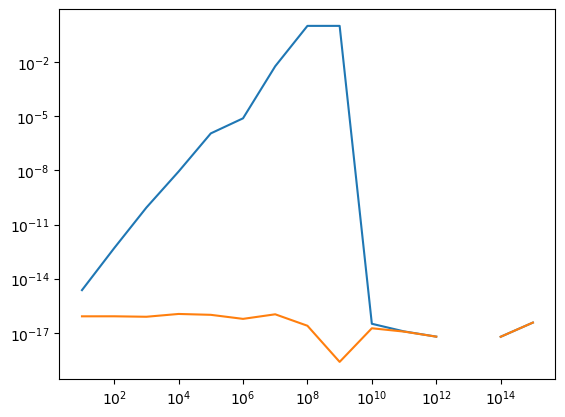

/tmp/ipykernel_376564/1963407845.py:43: RuntimeWarning: invalid value encountered in sqrt
  x1_std = 1/ (k + np.sqrt(k**2 - 1))
/tmp/ipykernel_376564/1963407845.py:44: RuntimeWarning: invalid value encountered in sqrt
  x2_std = k + np.sqrt(k**2 - 1)


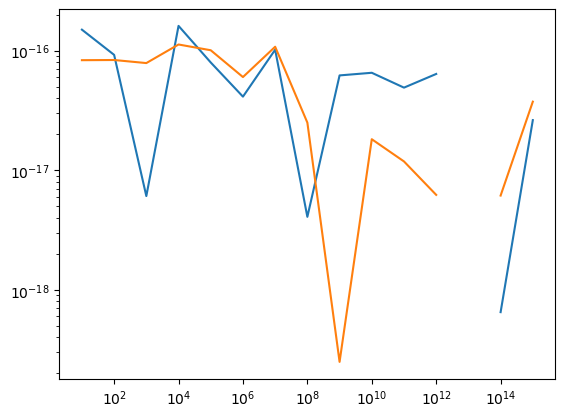

In [11]:
import numpy as np
import scipy.linalg as spl
import sympy as sym
import matplotlib.pyplot as plt

ks = 10**np.arange(1, 17)

x1_err = []
x2_err = []

for k in ks :
    # Definiamo i valori di riferimento ad alta precisione sym.N(espressione, 50)
    # risolvendo la funzione ho x1 = k - sqrt(k**2 - 1) e x2 = x1 = k + sqrt(k**2 - 1)
    x1_ref = sym.N(k - sym.sqrt(k**2 - 1), 50)
    x2_ref = sym.N(k + sym.sqrt(k**2 - 1), 50)

    #forlume standar 
    x1_std = k - np.sqrt(k**2 - 1)
    x2_std = k + np.sqrt(k**2 - 1)

    err1 = np.abs(x1_std - x1_ref) / np.abs(x1_ref)
    err2 = np.abs(x2_std - x2_ref) / np.abs(x2_ref)

    x1_err.append(float(err1))
    x2_err.append(float(err2))

plt.loglog(ks, x1_err, ks, x2_err)
plt.show()
 
# per risolvere il proble il punto problematico è k - np.sqrt(k**2 - 1) qui con quel meno che porta alla perdita di precisione  faccio una razionalizzazione al numeratore
#in questo modo non c'è piu una sostrazzione a rischio di cancellazione

x1_err = []
x2_err = []

for k in ks :
    # Definiamo i valori di riferimento ad alta precisione sym.N(espressione, 50)
    # risolvendo la funzione ho x1 = k - sqrt(k**2 - 1) e x2 = x1 = k + sqrt(k**2 - 1)
    x1_ref = sym.N(1/(k + sym.sqrt(k**2 - 1)), 50)
    x2_ref = sym.N(k + sym.sqrt(k**2 - 1), 50)

    #forlume standar 
    x1_std = 1/ (k + np.sqrt(k**2 - 1))
    x2_std = k + np.sqrt(k**2 - 1)

    err1 = np.abs(x1_std - x1_ref) / np.abs(x1_ref)
    err2 = np.abs(x2_std - x2_ref) / np.abs(x2_ref)

    x1_err.append(float(err1))
    x2_err.append(float(err2))

plt.loglog(ks, x1_err, ks, x2_err)
plt.show()

#si va ad usare la formula si usa la proprietà che x1*x2=a/c=1 da cui x1=1/x2

La radice che soffre di maggiore instabilità è la x1 (quella con un meno nella formula). L'instabilità è data dal fatto che il deltà è approssimativamente k e quindi k-k è data solo dalle cifre meno significative che il risultato di errori di arrotondamento precedentemente accumulati distruggendo l'accuratezza delal soluzione. i buchi nel grafico sono dati essendo k cosi grande se gli si somma 1 questo è più piccolo dello spacing necessario per far passare k al numero successivo quindi rimane k che da un delta uguale a ka e quindi x1=0 e l'errore relativo=1